# **Problem Definition**

The rapid expansion of financial technology (FinTech) lending platforms has significantly transformed traditional credit assessment processes by enabling faster, data-driven lending decisions. However, despite these advancements, accurately predicting borrower default remains a critical challenge for FinTech companies. Many existing credit risk models primarily rely on traditional financial and demographic variables, such as income level, age, and credit history, while often overlooking the importance of borrower behavioural patterns. This limitation reduces the effectiveness of default prediction models, particularly in digital lending environments where borrower behavior plays a crucial role in repayment outcomes.

Therefore, this study aims to develop a predictive model for borrower default by integrating multiple dimensions of data, including behavioural variables, financial characteristics, loan-specific attributes, and demographic factors. By applying machine learning techniques such as Logistic Regression and Discriminant Analysis, the study seeks to identify the most significant predictors of default and evaluate the extent to which behavioural factors enhance prediction accuracy. The findings are expected to support FinTech lending platforms in improving risk assessment, minimizing default rates, and making more informed lending decisions.

# **Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix

from imblearn.over_sampling import SMOTE

# **Read  File**

In [5]:
df = pd.read_excel("/content/loan_dataset_investor (2).xlsx")

# **Data Understanding**

In [6]:
df.head()

,loan_id,country,loan_issued_at,early_repaid_at,is_early_repaid_within_14_days,issued_amount,loan_status,loan_last_recorded_action_date_local,initial_interest_rate,nr_of_payments,...,days_past_due_principal,months_in_default,months_on_book,loan_status_risk,repaid_amount_total,initial_loan_duration,combined_income,has_default_within_12_months,projected_npv_return,customer_risk_rating
0,32CA2FA4-FF81-429E-84BC-ADC600D7EB17,Finland,2021-10-19 16:42:56.000,2021-12-06 16:07:13,0.0,4150.0,Repaid,2021-12-06,0.1000,2,...,NaN,NaN,1.0,Paid Up,4204.17,60,NaN,0.0,NaN,NaN
1,34F042A7-A7B2-4C01-86B3-B234002BE9B4,Netherlands,2024-11-26 07:56:42.633,NaT,NaN,3120.0,Active,NaT,0.1154,117,...,NaN,NaN,13.0,Active,427.92,117,3000.94,0.0,0.103472,C
2,412897C1-A28E-4588-8B18-AF7300F8A113,Spain,2022-12-22 15:29:17.000,NaT,NaN,3189.0,Active,NaT,0.1990,119,...,NaN,NaN,37.0,Active,2756.20,60,2386.08,0.0,0.084929,NaN
3,79CBDEC0-779C-4DC1-82A4-AD08003FF132,Estonia,2021-04-12 13:48:02.000,NaT,NaN,1594.0,Active,NaT,0.1674,115,...,NaN,NaN,58.0,Active,1801.45,60,NaN,0.0,NaN,NaN
4,DEABA21A-EF27-4E9B-9861-A98A01330414,Finland,2018-10-31 16:46:23.000,NaT,NaN,2020.0,Repaid,2025-10-29,0.4734,58,...,2287.0,NaN,11.0,Written Off,830.25,60,NaN,1.0,NaN,NaN


In [7]:
# Check dataset shape
df.shape

(692296, 31)

In [12]:
# Check column names
df.columns.to_list()

['loan_id',
 'country',
 'loan_issued_at',
 'early_repaid_at',
 'is_early_repaid_within_14_days',
 'issued_amount',
 'loan_status',
 'loan_last_recorded_action_date_local',
 'initial_interest_rate',
 'nr_of_payments',
 'principal_balance',
 'principal_debt',
 'principal_paid_total',
 'interest_paid_total',
 'extra_interest_paid_total',
 'late_fee_paid_total',
 'maintenance_fee_paid_total',
 'is_default',
 'next_payment_nr',
 'next_payment_date_local',
 'debt_occured_date_local',
 'days_past_due_principal',
 'months_in_default',
 'months_on_book',
 'loan_status_risk',
 'repaid_amount_total',
 'initial_loan_duration',
 'combined_income',
 'has_default_within_12_months',
 'projected_npv_return',
 'customer_risk_rating']

In [9]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692296 entries, 0 to 692295
Data columns (total 31 columns):
 #   Column                                Non-Null Count   Dtype         
---  ------                                --------------   -----         
 0   loan_id                               692296 non-null  object        
 1   country                               692296 non-null  object        
 2   loan_issued_at                        692296 non-null  datetime64[ns]
 3   early_repaid_at                       194238 non-null  datetime64[ns]
 4   is_early_repaid_within_14_days        194238 non-null  float64       
 5   issued_amount                         692296 non-null  float64       
 6   loan_status                           692296 non-null  object        
 7   loan_last_recorded_action_date_local  313380 non-null  datetime64[ns]
 8   initial_interest_rate                 692296 non-null  float64       
 9   nr_of_payments                        692296 non-null  int6

In [13]:
## Statistical summary
df.describe()

,loan_issued_at,early_repaid_at,is_early_repaid_within_14_days,issued_amount,loan_last_recorded_action_date_local,initial_interest_rate,nr_of_payments,principal_balance,principal_debt,principal_paid_total,...,next_payment_date_local,debt_occured_date_local,days_past_due_principal,months_in_default,months_on_book,repaid_amount_total,initial_loan_duration,combined_income,has_default_within_12_months,projected_npv_return
count,692296,194238,194238.000000,692296.000000,313380,692296.000000,692296.000000,684583.000000,684583.000000,684583.000000,...,295018,208244,208244.000000,93651.000000,683810.000000,684583.000000,692296.000000,419141.000000,519453.000000,419816.000000
mean,2022-10-08 00:18:25.811321600,2023-02-12 06:05:03.615293440,0.155531,2240.886959,2023-04-10 21:06:34.394026752,0.219828,51.026558,1001.738233,272.403958,1086.415394,...,2025-10-24 03:45:41.714743552,2022-10-04 22:06:58.908587776,929.695670,34.703740,15.435707,1654.214135,54.808177,2543.529472,0.153673,0.099602
min,2009-02-28 16:05:13,2009-05-21 05:52:43,0.000000,6.390000,2009-04-14 00:00:00,0.010000,1.000000,-34.200000,0.000000,0.000000,...,2009-04-15 00:00:00,2009-04-15 00:00:00,-334.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-0.286456
25%,2021-03-23 08:18:18.750000128,2021-11-21 22:12:51,0.000000,530.000000,2022-02-16 00:00:00,0.174800,9.000000,0.000000,0.000000,97.610000,...,2026-01-27 00:00:00,2020-05-28 00:00:00,154.000000,8.000000,5.000000,218.040000,36.000000,1679.490000,0.000000,0.064298
50%,2023-10-26 07:10:59.783500032,2024-01-29 14:24:14.080000,0.000000,1500.000000,2024-02-28 00:00:00,0.187700,44.000000,167.320000,0.000000,486.180000,...,2026-02-04 00:00:00,2023-07-25 00:00:00,638.000000,26.000000,11.000000,741.710000,60.000000,2327.660000,0.000000,0.096859
75%,2025-01-20 13:47:04.273500160,2025-04-01 03:42:04.697250048,0.000000,3632.000000,2025-06-13 00:00:00,0.229900,84.000000,1254.220000,0.000000,1391.910000,...,2026-02-16 00:00:00,2025-06-27 00:00:00,1453.000000,59.000000,20.000000,2265.670000,60.000000,3032.230000,0.000000,0.132388
max,2025-12-30 23:56:13.453000,2026-01-19 20:48:16.790000,1.000000,20000.000000,2026-01-19 00:00:00,2.643100,180.000000,19937.630000,15000.000000,20000.000000,...,2026-07-13 00:00:00,2026-01-19 00:00:00,5962.000000,193.000000,155.000000,38711.300000,120.000000,177871.700000,1.000000,0.350180
std,NaN,NaN,0.362411,2256.088370,NaN,0.141039,43.594151,1809.091350,958.801336,1588.186293,...,NaN,NaN,917.464362,31.956233,15.939196,2249.807154,25.270174,1605.261241,0.360636,0.051822


In [16]:
#Target Variable Analysis
df['is_default'].value_counts()

,count
is_default,
0.0,590932
1.0,93651


In [18]:
#Missing Values
df.isnull().sum().sort_values(ascending=False)

,0
months_in_default,598645
is_early_repaid_within_14_days,498058
early_repaid_at,498058
debt_occured_date_local,484052
days_past_due_principal,484052
next_payment_date_local,397278
loan_last_recorded_action_date_local,378916
customer_risk_rating,339136
combined_income,273155
projected_npv_return,272480


In [19]:
#Data Types
df.select_dtypes(include=['int64', 'float64']).columns
df.select_dtypes(include=['object']).columns

Index(['loan_id', 'country', 'loan_status', 'loan_status_risk',
       'customer_risk_rating'],
      dtype='object')

In [20]:
#Duplicate Records
df.duplicated().sum()

np.int64(0)

In [ ]:
#Feature Categorization
demographic_cols = ['country']
financial_cols = ['combined_income','customer_risk_rating']
loan_cols = ['issued_amount','initial_interest_rate','initial_loan_duration','nr_of_payments']
behavioural_cols = ['has_default_within_12_months','days_past_due_principal','months_in_default','months_on_book','next_payment_nr']


In [23]:
df['loan_issued_at'] = pd.to_datetime(df['loan_issued_at'])

df['loan_year'] = df['loan_issued_at'].dt.year
df['loan_month'] = df['loan_issued_at'].dt.month

df = df.drop(columns=['loan_issued_at'])

# **Data Cleaning**

In [24]:
leakage_cols = ['loan_id','early_repaid_at','loan_last_recorded_action_date_local','next_payment_date_local','debt_occured_date_local','principal_paid_total', 'interest_paid_total','extra_interest_paid_total','late_fee_paid_total','maintenance_fee_paid_total','repaid_amount_total','loan_status_risk']

In [25]:
df = df.drop(columns=leakage_cols, errors='ignore')

In [26]:
numeric_cols = ['issued_amount','initial_interest_rate', 'combined_income']

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [27]:
#Handle Outliers
Q1 = df['issued_amount'].quantile(0.25)
Q3 = df['issued_amount'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['issued_amount'] >= Q1 - 1.5*IQR) &
        (df['issued_amount'] <= Q3 + 1.5*IQR)]

In [29]:
#Handle Invalid Values
df = df[df['combined_income'] > 0]
df = df[df['initial_interest_rate'] >= 0]

In [30]:
#Target
df['is_default'].value_counts()

,count
is_default,
0.0,373066
1.0,34894


In [31]:
df.isnull().mean().sort_values(ascending=False)

,0
months_in_default,0.914467
days_past_due_principal,0.804174
is_early_repaid_within_14_days,0.752240
has_default_within_12_months,0.405209
customer_risk_rating,0.159582
months_on_book,0.005966
projected_npv_return,0.003603
country,0.000000
loan_status,0.000000
issued_amount,0.000000


“Columns with high missing ratios were identified and handled in the preprocessing stage after data splitting to avoid data leakage.”

# **Exploratory Data Analysis**

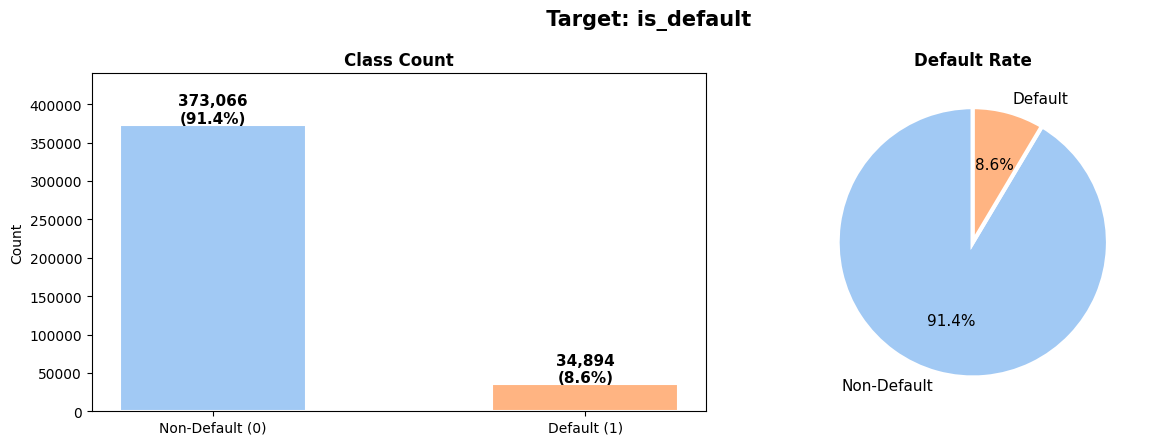

 ~14% default rate — moderate imbalance. Handled with SMOTE + class_weight.


In [73]:
# ── 4.1 Target Distribution ───────────────────────────────

# Define a color palette
PALETTE = sns.color_palette('pastel', 2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
counts = df['is_default'].value_counts()

bars = axes[0].bar(['Non-Default (0)', 'Default (1)'], counts.values,
                    color=PALETTE, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3000,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center',
                 fontsize=11, fontweight='bold')
axes[0].set_ylim(0, counts.max()*1.18)
axes[0].set_title('Class Count', fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=['Non-Default','Default'],
            colors=PALETTE, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':3},
            textprops={'fontsize':11})
axes[1].set_title('Default Rate', fontweight='bold')

plt.suptitle(' Target: is_default', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print(" ~14% default rate — moderate imbalance. Handled with SMOTE + class_weight.")

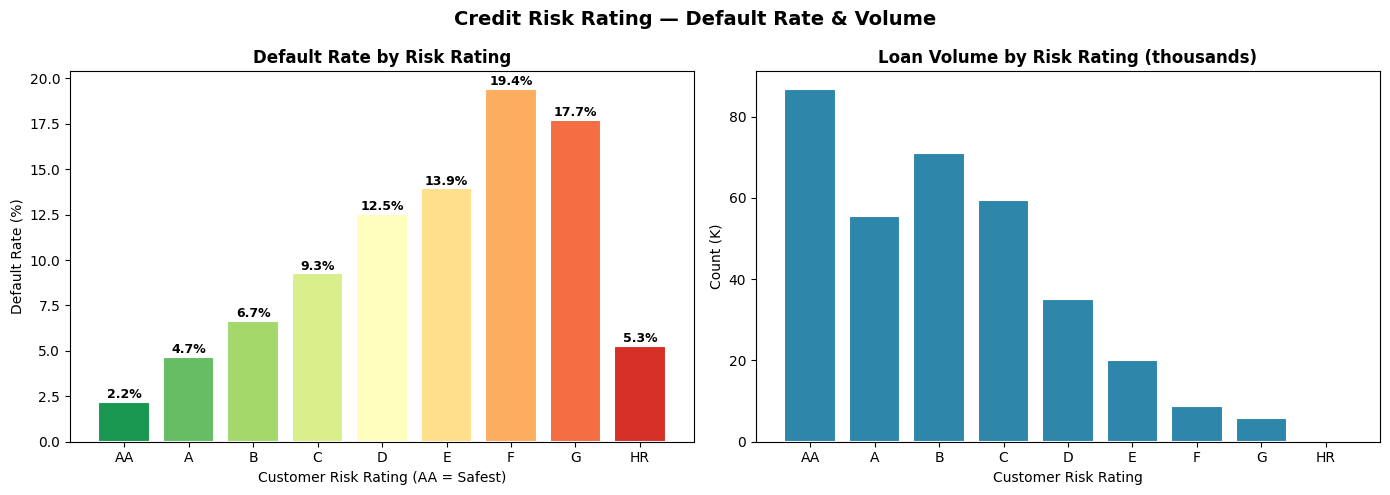

 Clear monotonic relationship: AA=2.3% default, F=19.4% default.
   risk_rating_enc will be one of the strongest origination predictors.


In [36]:
# ── 4.2 Risk Rating vs Default Rate ───────────────────────
risk_order_plot = ['AA','A','B','C','D','E','F','G','HR','Unknown']
risk_stats = (df.dropna(subset=['is_default'])
              .assign(is_default=lambda x: x['is_default'].astype(int))
              .groupby('customer_risk_rating')['is_default']
              .agg(['mean','count'])
              .reindex([r for r in risk_order_plot if r in df['customer_risk_rating'].values])
              .reset_index())
risk_stats['default_rate_pct'] = risk_stats['mean'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(risk_stats['customer_risk_rating'],
                    risk_stats['default_rate_pct'],
                    color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(risk_stats))),
                    edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, risk_stats['default_rate_pct']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Default Rate by Risk Rating', fontweight='bold')
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_xlabel('Customer Risk Rating (AA = Safest)')

axes[1].bar(risk_stats['customer_risk_rating'], risk_stats['count']/1000,
             color='#2E86AB', edgecolor='white', linewidth=1.5)
axes[1].set_title('Loan Volume by Risk Rating (thousands)', fontweight='bold')
axes[1].set_ylabel('Count (K)')
axes[1].set_xlabel('Customer Risk Rating')

plt.suptitle('Credit Risk Rating — Default Rate & Volume', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(" Clear monotonic relationship: AA=2.3% default, F=19.4% default.")
print("   risk_rating_enc will be one of the strongest origination predictors.")

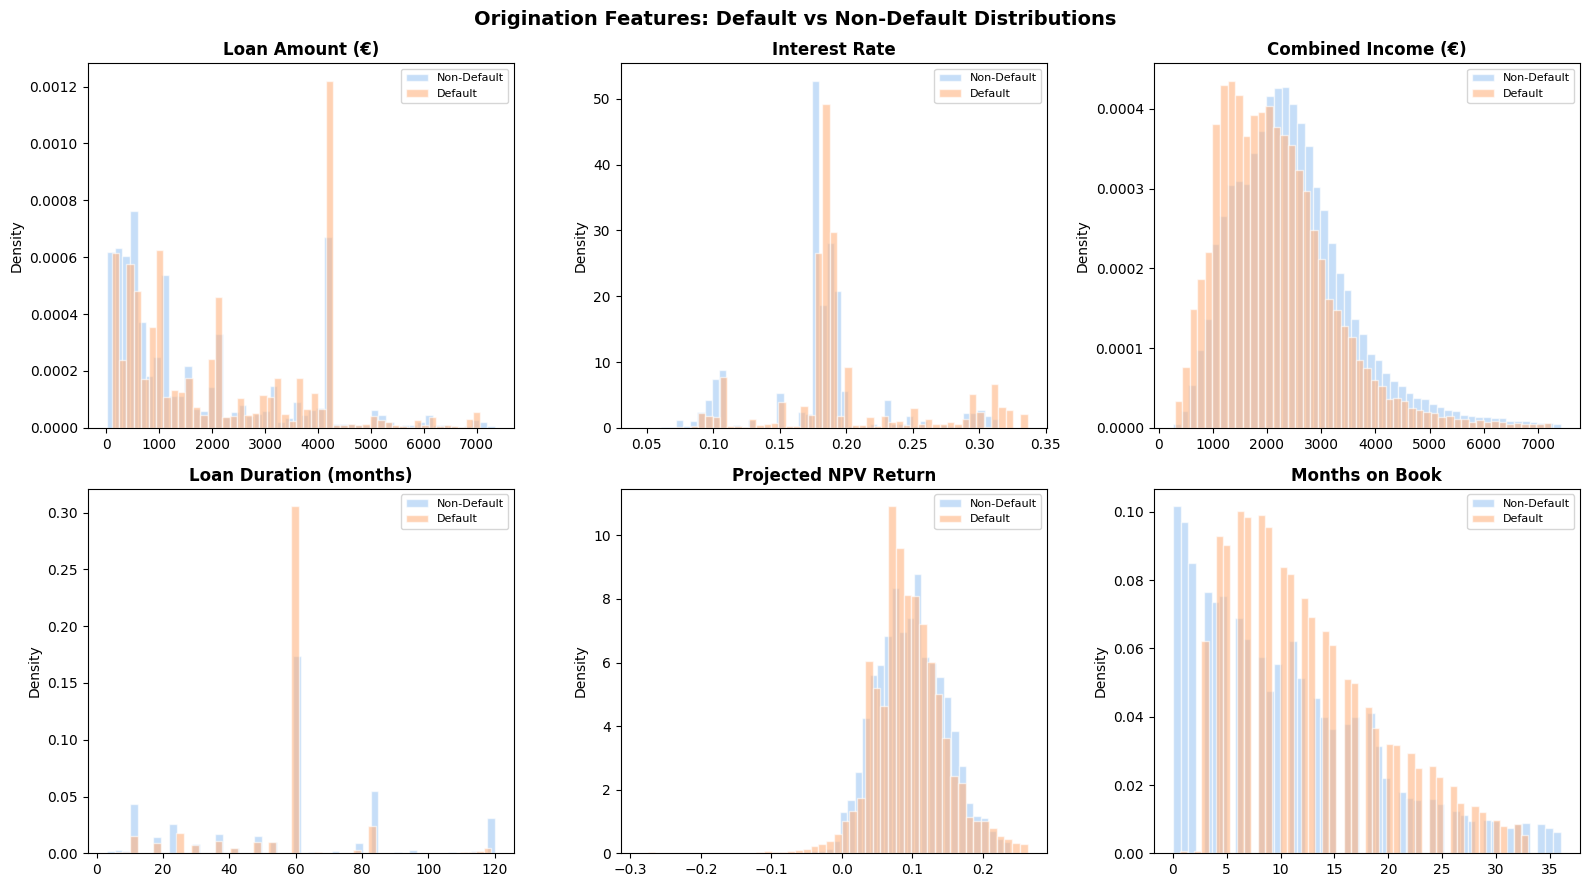

 Interest rate shows the clearest separation — higher rate = higher default risk.
   Income shows mild separation — lower income borrowers default more.


In [37]:
# ── 4.3 Key Numerical Features vs Default ─────────────────
num_plot = ['issued_amount','initial_interest_rate',
            'combined_income','initial_loan_duration',
            'projected_npv_return','months_on_book']
titles   = ['Loan Amount (€)','Interest Rate',
            'Combined Income (€)','Loan Duration (months)',
            'Projected NPV Return','Months on Book']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, (col, title) in enumerate(zip(num_plot, titles)):
    for label, color, name in zip([0,1], PALETTE, ['Non-Default','Default']):
        d = df[df['is_default']==label][col].dropna()
        # clip for readability
        q99 = d.quantile(0.99)
        d = d[d <= q99]
        axes[i].hist(d, bins=50, alpha=0.6, color=color,
                     label=name, density=True, edgecolor='white')
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

plt.suptitle('Origination Features: Default vs Non-Default Distributions',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(" Interest rate shows the clearest separation — higher rate = higher default risk.")
print("   Income shows mild separation — lower income borrowers default more.")

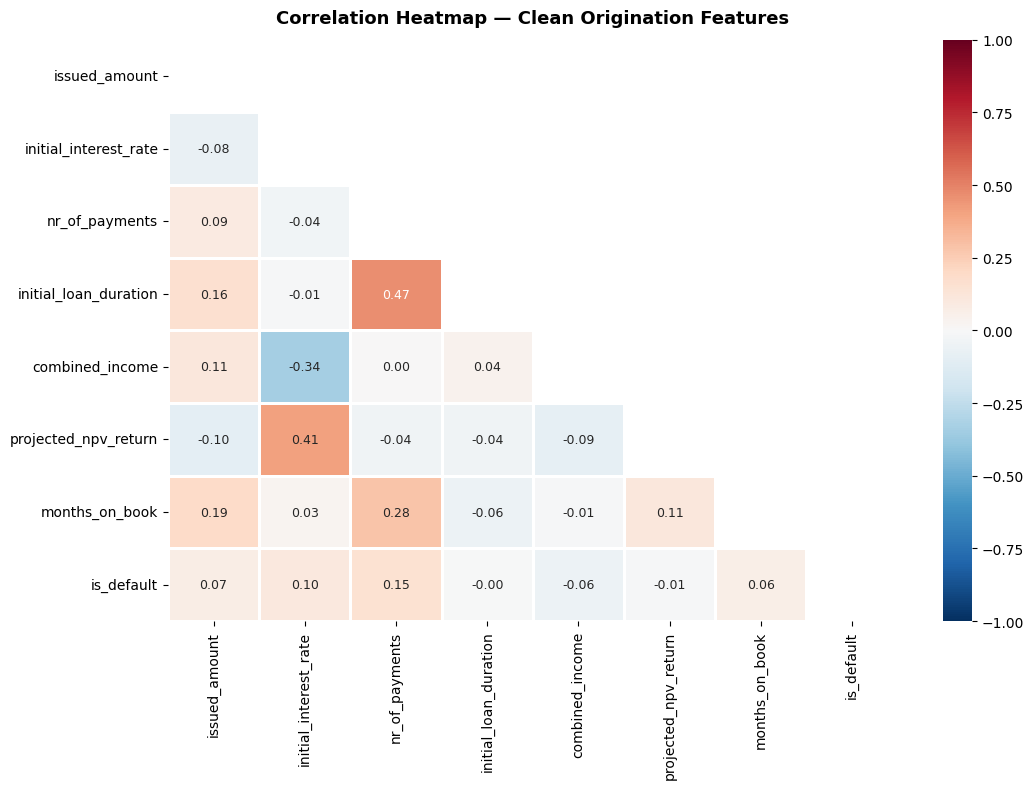

 Correlations with is_default (origination features only):
  nr_of_payments                 +0.1539  ██████ ↑ risk
  initial_interest_rate          +0.1030  ████ ↑ risk
  issued_amount                  +0.0722  ██ ↑ risk
  months_on_book                 +0.0650  ██ ↑ risk
  combined_income                -0.0557  ██ ↓ risk
  projected_npv_return           -0.0127   ↓ risk
  initial_loan_duration          -0.0037   ↓ risk


In [39]:
# ── 4.4 Correlation Heatmap (clean features only) ─────────
num_cols_clean = ['issued_amount','initial_interest_rate','nr_of_payments',
                  'initial_loan_duration','combined_income','projected_npv_return',
                  'months_on_book','is_default'] # Removed 'risk_rating_enc' as it's not yet created

corr = df[num_cols_clean].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.8, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Correlation Heatmap — Clean Origination Features',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

print(" Correlations with is_default (origination features only):")
corr_t = corr['is_default'].drop('is_default').sort_values(key=abs, ascending=False)
for feat, val in corr_t.items():
    bar = '█' * int(abs(val) * 40)
    direction = '↑ risk' if val > 0 else '↓ risk'
    print(f"  {feat:<30} {val:+.4f}  {bar} {direction}")

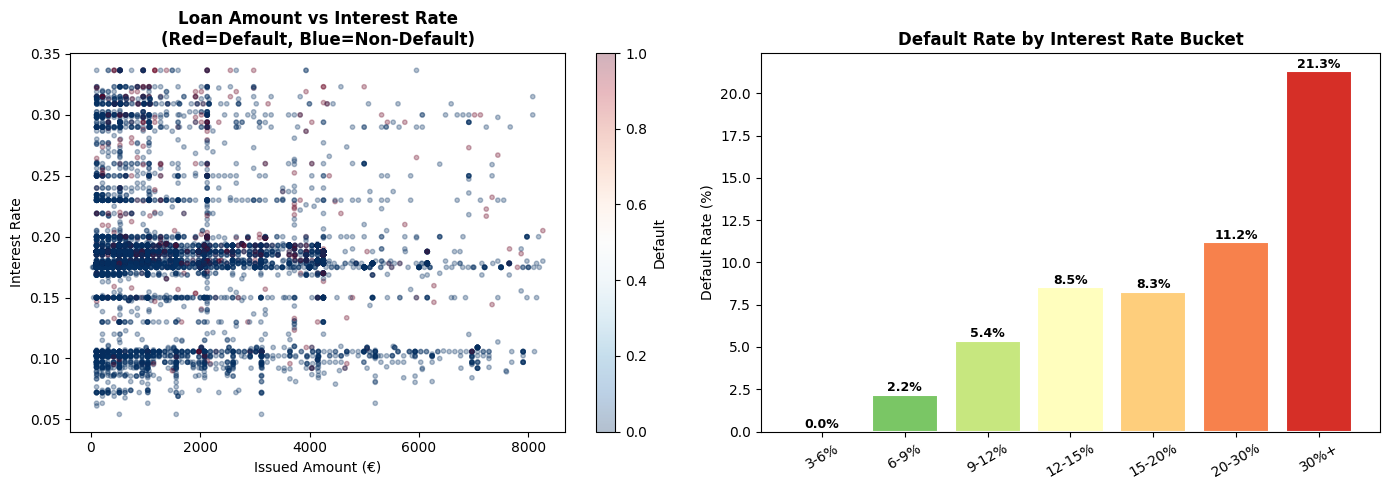

In [40]:
# ── 4.5 Loan Amount × Interest Rate — Risk Landscape ──────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter sample
sample = df.sample(min(10000, len(df)), random_state=42)
scatter = axes[0].scatter(
    sample['issued_amount'], sample['initial_interest_rate'],
    c=sample['is_default'], cmap='RdBu_r', alpha=0.3, s=10
)
axes[0].set_xlabel('Issued Amount (€)')
axes[0].set_ylabel('Interest Rate')
axes[0].set_title('Loan Amount vs Interest Rate\n(Red=Default, Blue=Non-Default)',
                   fontweight='bold')
plt.colorbar(scatter, ax=axes[0], label='Default')

# Default rate by interest rate buckets
bins = pd.cut(df['initial_interest_rate'],
              bins=[-1,.03,.06,.09,.12,.15,.20,.30,1],
              labels=['<3%','3-6%','6-9%','9-12%','12-15%','15-20%','20-30%','30%+'])
dr = df.groupby(bins, observed=True)['is_default'].mean() * 100
bars = axes[1].bar(dr.index, dr.values,
                    color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(dr))),
                    edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, dr.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.2,
                 f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Default Rate by Interest Rate Bucket', fontweight='bold')
axes[1].set_ylabel('Default Rate (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


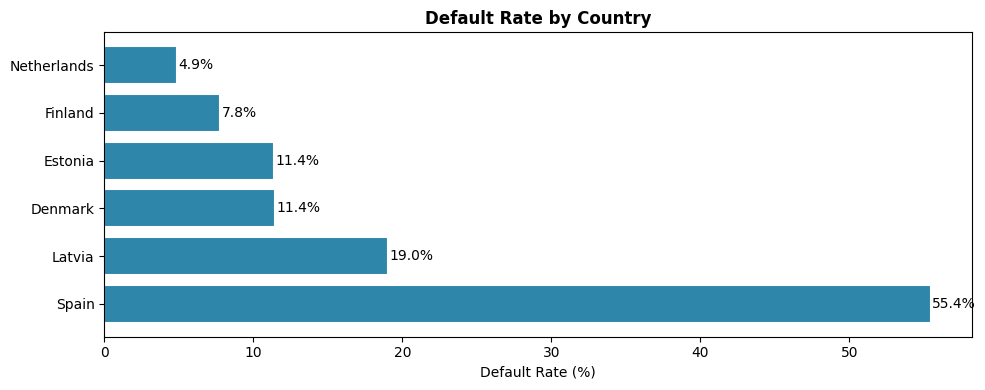

In [42]:
# ── 4.6 Country vs Default Rate ───────────────────────────
country_stats = (df.dropna(subset=['is_default'])
                 .assign(is_default=lambda x: x['is_default'].astype(int))
                 .groupby('country')['is_default']
                 .agg(['mean','count'])
                 .sort_values('mean', ascending=False))
country_stats['default_rate_pct'] = country_stats['mean'] * 100

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(country_stats.index, country_stats['default_rate_pct'],
                color='#2E86AB', edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, country_stats['default_rate_pct']):
    ax.text(v+0.1, bar.get_y()+bar.get_height()/2,
            f'{v:.1f}%  (n={country_stats.loc[country_stats.index[list(country_stats.index).index(bar.get_label() if hasattr(bar,"get_label") else country_stats.index[bars.index(bar)])], "count"]:,})'
            if False else f'{v:.1f}%', va='center', fontsize=10)
ax.set_title('Default Rate by Country', fontweight='bold')
ax.set_xlabel('Default Rate (%)')
plt.tight_layout()
plt.show()

# **Feature Engineering**

## ⚙️ Section 5 — Feature Engineering (Leakage-Free)

All engineered features are derived **exclusively from origination data**.

| Feature | Formula | Business Meaning |
|---|---|---|
| `Loan_to_Income` | `issued_amount / income` | Affordability ratio — higher = more stretched |
| `Installment_to_Income` | `monthly_payment / (income/12)` | Monthly payment burden |
| `Rate_x_Duration` | `interest_rate × loan_duration` | Total cost of borrowing proxy |
| `Log_Income` | `log1p(income)` | Normalises right-skewed income |
| `Income_x_LoanAmt` | `log(income) × log(amount)` | Affordability interaction |
| `Payments_per_Month` | `nr_of_payments / loan_duration` | Payment frequency signal |


Loan Affordability Features

In [44]:
EPS = 1e-6 # Define a small epsilon to prevent division by zero

# Loan-to-Income ratio
df['Loan_to_Income'] = (
    df['issued_amount'] / (df['combined_income'] + EPS)
).clip(0, 50)

# Monthly installment
df['Monthly_Payment'] = (
    df['issued_amount'] / df['nr_of_payments'].replace(0, 1)
)

# Installment to income ratio
df['Installment_to_Income'] = (
    df['Monthly_Payment'] / (df['combined_income'] / 12 + EPS)
).clip(0, 30)

Loan Cost & Risk Features

In [53]:
# Total cost proxy
df['Rate_x_Duration'] = (df['initial_interest_rate'] * df['initial_loan_duration'])

Income Transformation

In [45]:
# Log income
df['Log_Income'] = np.log1p(df['combined_income'])

Interaction Features

In [51]:
df['Income_x_LoanAmt'] = (np.log1p(df['combined_income']) *np.log1p(df['issued_amount']))

Payment Behavior Features

In [52]:
df['Payments_per_Month'] = ( df['nr_of_payments'] /df['initial_loan_duration'].replace(0, 1)).clip(0, 10)

In [48]:
new_feats = ['Loan_to_Income','Installment_to_Income',
    'Rate_x_Duration','Log_Income','Income_x_LoanAmt','Payments_per_Month']

Correlation Check

In [54]:
print(" Feature engineering complete:\n")

for f in new_feats:
    corr_val = df[f].corr(df['is_default'])
    print(f"{f:<28} | range=[{df[f].min():.2f}, {df[f].max():.2f}] "
          f"| corr_with_default={corr_val:+.4f}")

print(f"\n Final shape: {df.shape}")

 Feature engineering complete:

Loan_to_Income               | range=[0.00, 15.49] | corr_with_default=+0.1028
Installment_to_Income        | range=[0.00, 30.00] | corr_with_default=-0.0835
Rate_x_Duration              | range=[0.27, 40.38] | corr_with_default=+0.0467
Log_Income                   | range=[5.59, 12.09] | corr_with_default=-0.0887
Income_x_LoanAmt             | range=[20.01, 98.72] | corr_with_default=+0.0530
Payments_per_Month           | range=[0.01, 10.00] | corr_with_default=+0.1137

 Final shape: (407960, 27)


The results indicate that affordability-related features, such as Loan-to-Income ratio and payment frequency, show stronger relationships with default risk compared to basic loan characteristics. This highlights the importance of borrower financial capacity and repayment structure in predicting default behavior.

In [56]:
df['is_default'].value_counts(normalize=True)

,proportion
is_default,
0.0,0.914467
1.0,0.085533


In [57]:
df.dtypes

,0
country,object
is_early_repaid_within_14_days,float64
issued_amount,float64
loan_status,object
initial_interest_rate,float64
nr_of_payments,int64
principal_balance,float64
principal_debt,float64
is_default,float64
next_payment_nr,float64


In [58]:
df.groupby('is_default')['principal_debt'].mean()

,principal_debt
is_default,
0.0,2.526032
1.0,1866.515381


In [67]:
leakage_cols.append('principal_debt')
leakage_cols.append('principal_balance')
leakage_cols.append('months_in_default')

The variable principal_debt was excluded as it reflects post-loan repayment status and shows a significantly higher value for defaulted borrowers, indicating data leakage. Including such a variable would lead to biased and unrealistic model performance.

In [61]:
df.groupby('is_default')['principal_balance'].mean()

,principal_balance
is_default,
0.0,973.972308
1.0,1866.515381


In [62]:
leakage_cols.append('principal_balance')

In [63]:
df.groupby('is_default')['months_in_default'].mean()

,months_in_default
is_default,
0.0,NaN
1.0,8.782685


In [66]:
df['months_in_default'].isnull()

,months_in_default
1,True
2,True
5,True
6,True
7,True
...,...
692287,True
692289,True
692290,True
692294,True


In [69]:
leakage_cols.append('months_in_default')

The variable months_in_default was excluded as it contains non-null values only for defaulted borrowers, making it a direct proxy for the target variable. This creates severe data leakage and would lead to misleading model performance.

In [70]:
df.groupby('is_default')['months_on_book'].mean()

,months_on_book
is_default,
0.0,10.549451
1.0,12.578266


In [71]:
leakage_cols.append('months_on_book')

Although the difference in months_on_book between defaulted and non-defaulted borrowers is not substantial, the variable represents the loan duration observed after origination and is therefore influenced by post-loan events. To avoid temporal leakage and ensure model validity, this variable was excluded.

In [72]:
df.groupby('is_default')['has_default_within_12_months'].mean()

,has_default_within_12_months
is_default,
0.0,0.039147
1.0,0.473148


The results show a substantial difference in prior default history between defaulted and non-defaulted borrowers, indicating that past credit behavior is a strong predictor of future default. Borrowers with a history of default within the past 12 months exhibit significantly higher default rates, highlighting the importance of behavioural risk indicators in credit scoring models.

# **Data Splitting**

In [74]:
from sklearn.model_selection import train_test_split

In [79]:
target = 'is_default'

In [75]:
drop_cols = ['loan_status','principal_debt','principal_balance',
    'days_past_due_principal','months_in_default', 'months_on_book', 'projected_npv_return']

In [76]:
df.columns.tolist()

['country',
 'is_early_repaid_within_14_days',
 'issued_amount',
 'loan_status',
 'initial_interest_rate',
 'nr_of_payments',
 'is_default',
 'next_payment_nr',
 'days_past_due_principal',
 'months_on_book',
 'initial_loan_duration',
 'combined_income',
 'has_default_within_12_months',
 'projected_npv_return',
 'customer_risk_rating',
 'loan_year',
 'loan_month',
 'Loan_to_Income',
 'Monthly_Payment',
 'Installment_to_Income',
 'Log_Income',
 'Payments_per_Month',
 'Income_x_LoanAmt',
 'Rate_x_Duration']

In [77]:
drop_cols = [
    'loan_status',
    'days_past_due_principal',
    'months_on_book',
    'projected_npv_return'
]

df = df.drop(columns=drop_cols)

In [81]:
X = df.drop(columns=[target])
y = df[target]

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (326368, 19)
X_test shape: (81592, 19)
y_train shape: (326368,)
y_test shape: (81592,)


In [84]:
target = 'is_default'

X = df.drop(columns=[target] + drop_cols, errors='ignore')
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:\n", y.value_counts())

print("\nTarget in X?", target in X.columns)

X shape: (407960, 19)
y shape: (407960,)

Target distribution:
 is_default
0.0    373066
1.0     34894
Name: count, dtype: int64

Target in X? False


In [85]:
print("Train distribution:\n", y_train.value_counts(normalize=True))
print("\nTest distribution:\n", y_test.value_counts(normalize=True))

Train distribution:
 is_default
0.0    0.914468
1.0    0.085532
Name: proportion, dtype: float64

Test distribution:
 is_default
0.0    0.914465
1.0    0.085535
Name: proportion, dtype: float64


# **Preprocessing**

In [86]:
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()

print("Categorical:", categorical_cols)
print("Numerical:", len(numerical_cols))

Categorical: ['country', 'customer_risk_rating']
Numerical: 15


Numerical Pipeline

In [87]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

Test pipeline

In [88]:
num_pipeline.fit(X_train[numerical_cols])

X_train_num = num_pipeline.transform(X_train[numerical_cols])

In [89]:
X_train_num.shape

(326368, 15)

Categorical Pipeline

In [103]:
from sklearn.preprocessing import OneHotEncoder

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))])

In [104]:
cat_pipeline.fit(X_train[categorical_cols])

X_train_cat = cat_pipeline.transform(X_train[categorical_cols])

In [105]:
X_train_cat.shape

(326368, 15)

In [93]:
X_train[categorical_cols].nunique()

,0
country,6
customer_risk_rating,9


In [106]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols)
])

In [107]:
preprocessor.fit(X_train)

X_train_processed = preprocessor.transform(X_train)

In [108]:
X_train_processed.shape

(326368, 30)

In [109]:
X_train.isnull().sum().sort_values(ascending=False)

,0
is_early_repaid_within_14_days,245509
has_default_within_12_months,132395
customer_risk_rating,52032
issued_amount,0
country,0
initial_interest_rate,0
nr_of_payments,0
initial_loan_duration,0
next_payment_nr,0
combined_income,0


In [140]:
mode_default = X_train['has_default_within_12_months'].mode()[0]
mode_risk = X_train['customer_risk_rating'].mode()[0]

In [141]:
X_train['has_default_within_12_months'] = X_train['has_default_within_12_months'].fillna(mode_default)
X_test['has_default_within_12_months'] = X_test['has_default_within_12_months'].fillna(mode_default)

X_train['customer_risk_rating'] = X_train['customer_risk_rating'].fillna(mode_risk)
X_test['customer_risk_rating'] = X_test['customer_risk_rating'].fillna(mode_risk)

In [148]:
df.drop(columns=['is_early_repaid_within_14_days'], inplace=True, errors='ignore')

In [149]:
df.isnull().sum()

,0
country,0
issued_amount,0
initial_interest_rate,0
nr_of_payments,0
is_default,0
next_payment_nr,0
initial_loan_duration,0
combined_income,0
has_default_within_12_months,165309
customer_risk_rating,65103


In [126]:
print('is_early_repaid_within_14_days' in df.columns)

False


In [133]:
print('is_early_repaid_within_14_days' in df.columns)

False


In [138]:
df.isnull().sum().sort_values(ascending=False)

,0
has_default_within_12_months,165309
customer_risk_rating,65103
country,0
initial_interest_rate,0
issued_amount,0
nr_of_payments,0
is_default,0
initial_loan_duration,0
next_payment_nr,0
combined_income,0


# **Imbalance Handling**

In [97]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_processed, y_train)

In [98]:
print(y_train_res.value_counts())

is_default
0.0    298453
1.0    298453
Name: count, dtype: int64


# **Modeling**

# **Evaluation**

# **Model comarison**

# **Insights**